# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

Include a brief statement describing how and which AI was used (or if no AI was used) in completing the assignment. This could be a markdown cell with a couple of sentences. As a reminder, AI use is permitted in the assignments, but it is advisable to try to complete the tasks as far as possible without and to make sure you understand the code that AI produced when using it.

## Grading

This assignment is worth 10 points. Task 0 is worth 1 point, and tasks 1-2 are worth 2 points and task 3 is worth 5 points.

Points are given only for code that runs. If the code does not run, the task (or subtask if code for a task is divided into multiple cells) will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [10]:
#a

In [11]:
!ollama --version 
#i downloaded ollama locally and made sure it was the correct version

ollama version is 0.23.0


In [12]:
import requests

response = requests.get("http://localhost:11434/api/tags")

print("Status:", response.status_code)
print("Available models:", response.json()) #make sure that the model gemma3:270m is available for step b)

Status: 200
Available models: {'models': [{'name': 'gemma3:270m', 'model': 'gemma3:270m', 'modified_at': '2026-05-04T16:22:07.3883108+03:00', 'size': 291554930, 'digest': 'e7d36fb2c3b3293cfe56d55889867a064b3a2b22e98335f2e6e8a387e081d6be', 'details': {'parent_model': '', 'format': 'gguf', 'family': 'gemma3', 'families': ['gemma3'], 'parameter_size': '268.10M', 'quantization_level': 'Q8_0'}}]}


In [14]:
#b)

In [15]:
!ollama pull gemma3:270m

pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest â ´ pulling manifest â ¦ pulling manifest â § pulling manifest 
pulling 735af2139dc6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 291 MB                         
pulling 4b19ac7dd2fb: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  476 B                         
pulling 3e2c24001f9e: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 8.4 KB                         
pulling 339e884a40f6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�   61 B                         
pulling 74156d92caf6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  490 B                         
verifying sha256 digest 
writing manifest 
success 


In [31]:
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma3:270m",
        "prompt": "Describe the plot of the first Harry Potter book.",
        "stream": False
    }
)

print(response.json()["response"])

The first Harry Potter book, "Harry Potter and the Prisoner of Azkaban," tells the story of Harry Potter, a young boy who is forbidden from speaking with his parents due to a mysterious illness. He is then taken to Hogwarts School of Witchcraft and Wizardry, where he is chosen to be a student and be tutored by Professor McGonagall. 

The story unfolds as Harry is initially apprehensive about his newfound friends and his life in Hogwarts. He is forced to confront his fears and experiences, and learn to trust and rely on his friends. He starts to develop a strong sense of loyalty to his friends and a determination to overcome his fears.

As Harry navigates the challenges of his magical world, he also faces his own internal struggles and insecurities. He learns to manage his emotions, develop his self-confidence, and find a balance between his responsibility to his friends and his desire to live a normal life.

Throughout the book, Harry's journey is filled with adventure, discovery, and 

In [32]:
#c

In [28]:
!ollama pull gemma3:4b

pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest â ´ pulling manifest â ¦ pulling manifest â § pulling manifest â ‡ pulling manifest â � pulling manifest 
pulling aeda25e63ebd: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 3.3 GB                         
pulling e0a42594d802: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  358 B                         
pulling dd084c7d92a3: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 8.4 KB                         
pulling 3116c5225075: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�   77 B                         
pulling b6ae5839783f: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  489 B                         
verifying sha256 digest 
writing manifest 
success 


In [33]:
response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma3:4b",
        "prompt": "Describe the plot of the first Harry Potter book.",
        "stream": False
    }
)

print(response.json()["response"])

Okay, here’s a breakdown of the plot of *Harry Potter and the Philosopher’s Stone* (the first Harry Potter book):

**The Setup:**

Ten-year-old Harry Potter lives a miserable life with his cruel aunt, uncle, and cousin, the Dursleys. They treat him horribly, forbidding him to talk about his past and keeping him locked in a cupboard under the stairs. On his eleventh birthday, Harry receives a mysterious letter informing him that he is a wizard and has been accepted into Hogwarts School of Witchcraft and Wizardry.  He discovers he’s a “Wizard Boy” – meaning he’s a famous wizard who survived an attack by the dark wizard Lord Voldemort when he was a baby. 

**At Hogwarts:**

* **Arrival & Sorting:** Harry, along with his best friend Ron Weasley (a boy from a poor wizarding family) and Hermione Granger (a brilliant Muggle-born witch), attend their first year at Hogwarts. They are sorted into "Gryffindor" house by the Sorting Hat, a magical hat that determines which house a student belongs t

In [78]:
#the 4b version is much more accurate than the 270m that is full of inaccuracies

### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [35]:
import pandas as pd

In [44]:
df = pd.read_table('emails.csv')
df.head()

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review


In [45]:
#a

In [53]:
def classification_email(headline, model):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": "Classify this email headline as spam, work or unknown. "
                      "Return ONLY one word.\n"
                      "Headline: " + headline,
            "stream": False
        }
    )
    
    return response.json()["response"].strip()


In [ ]:
#b)

In [59]:
for headline in df['headline']:
    print(headline, '->', classification_email(headline , 'gemma3:270m'))

URGENT: Your account will be suspended within 24 hours -> Work
Congratulations! You have won a 1000€ gift card, claim now -> Work
Hot singles in your area are waiting to meet you tonight -> Work
Re: Inheritance transfer of 4.5M USD pending your approval -> Work
Meeting agenda for Thursday's project review -> Work
Q3 budget report attached, please review by Friday -> Work
Reminder: Annual performance review scheduled for next week -> Work
Updated draft of the manuscript, comments welcome -> Work
Quick question about last week -> Work
Following up -> Work
Important update regarding your recent activity -> Work
Are you available? -> Work


In [ ]:
#c)

In [61]:
for headline in df['headline']:
    print(headline, '->' , classification_email(headline , 'gemma3:4b'))

URGENT: Your account will be suspended within 24 hours -> Spam
Congratulations! You have won a 1000€ gift card, claim now -> Spam
Hot singles in your area are waiting to meet you tonight -> Spam
Re: Inheritance transfer of 4.5M USD pending your approval -> Spam
Meeting agenda for Thursday's project review -> Work
Q3 budget report attached, please review by Friday -> Work
Reminder: Annual performance review scheduled for next week -> Work
Updated draft of the manuscript, comments welcome -> Unknown
Quick question about last week -> Unknown
Following up -> Unknown
Important update regarding your recent activity -> Spam
Are you available? -> Unknown


In [62]:
#again, looks like the smaller version is much more innacurate. it has classified all the headlines as 'Work'.

In [63]:
#d)

In [68]:
df_repeat = pd.DataFrame(index=df['headline'])
df_repeat.head()

""
headline
URGENT: Your account will be suspended within 24 hours
"Congratulations! You have won a 1000€ gift card, claim now"
Hot singles in your area are waiting to meet you tonight
Re: Inheritance transfer of 4.5M USD pending your approval
Meeting agenda for Thursday's project review


In [73]:
for i in range(3): #does the classification 3 times with the 270m model and each time it appends a new column with the results
    df_repeat[f"270m_{i+1}"] = [
        classification_email(h, "gemma3:270m")
        for h in df_repeat.index
    ]

for i in range(3): #does the classification 3 times with the 4b model and each time it appends a new column with the results
    df_repeat[f"4b_{i+1}"] = [
        classification_email(h, "gemma3:4b")
        for h in df_repeat.index
    ]

In [75]:
df_repeat.head(12) #prints results

,270m_1,270m_2,270m_3,4b_1,4b_2,4b_3
headline,,,,,,
URGENT: Your account will be suspended within 24 hours,Work,Suspended,Suspended,Spam,Spam,Spam
"Congratulations! You have won a 1000€ gift card, claim now",Work,Work,Work,Spam,Spam,Spam
Hot singles in your area are waiting to meet you tonight,Work,Work,Work,Spam,Spam,Spam
Re: Inheritance transfer of 4.5M USD pending your approval,Work,Work,Work,Spam,Spam,Spam
Meeting agenda for Thursday's project review,Work,Work,Work,Work,Work,Work
"Q3 budget report attached, please review by Friday",Work,Work,Work,Work,Work,Work
Reminder: Annual performance review scheduled for next week,Work,Work,Work,Work,Work,Work
"Updated draft of the manuscript, comments welcome",Work,Work,Work,Unknown,Unknown,Unknown
Quick question about last week,Work,Work,Work,Unknown,Unknown,Unknown


In [76]:
#the 270m model was less consistent and kept returning invalid answers all of 3 times. it classified all headlines as 'Work' and even returned
#the word 'Suspended' which was not included in the function's Prompt.
#the 4b model classified the headlines more accurately and did a more reliable classification

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [98]:
df = pd.read_table('news.csv')
df.head()

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...


In [99]:
#a

In [100]:
import json

In [101]:
def classify_texts(headline, model):
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model": model,
            "prompt": "Classify this text as one of the following categories: earnings, mergers, regulation or macroeconomics.\n"
                      "Then, classify this text based on positive, negative or neutral sentiment. You can only pick one of the given options as a result.\n"
                      'Return only valid JSON format that looks like this: {"topic": "...", "sentiment": "..."}\n'
                      "Headline: " + headline,
            "stream": False
        }
    )

    text = response.json()["response"].strip()
    text = text.replace("```json", "").replace("```", "").strip()

    try:
        return json.loads(text)
    except:
        return {"topic": text , "sentiment": text} #this will return the text in json format

In [102]:
#b

In [103]:
topic = [] #empty topic list
sentiment = [] #empty sentiment list
for i in df['headline']:  #goes over all the headlines in the dataframe, classifies the text into categories based on topics and then based on sentiment
    result = classify_texts(i, 'gemma3:4b')
    topic.append(result['topic']) #appends classification results into topic list
    sentiment.append(result['sentiment']) #and sentiment list respectively
    
df['topic'] = topic
df['sentiment'] = sentiment

In [104]:
df

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,neutral
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,neutral
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


In [ ]:
#a)

In [112]:
df_task3 = pd.read_csv('bank-additional.csv', sep=';')

In [114]:
df_task3

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,...,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


In [117]:
df_task3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [118]:
df_task3.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [116]:
df_task3['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [122]:
#i will conduct exploratory data analysis in order to analyze how subscription is different across yhe different job categories,
# so that i can identify patterns useful for prediction of customer behaviour.

In [134]:
df_job = df_task3.groupby('job')['y'].value_counts().unstack()

In [135]:
df_job['yes']
    
    
    

job
admin.           133
blue-collar       61
entrepreneur       8
housemaid         11
management        30
retired           38
self-employed     13
services          35
student           19
technician        80
unemployed        19
unknown            4
Name: yes, dtype: int64

In [138]:
for i in df_job:
    df_job['perc_of_yes']=df_job['yes']/(df_job['yes']+df_job['no'])

In [139]:
df_job #now, we will be able to see the percentages that did subscribe, from each job category

y,no,yes,perc_of_yes
job,,,
admin.,879,133,0.131423
blue-collar,823,61,0.069005
entrepreneur,140,8,0.054054
housemaid,99,11,0.100000
management,294,30,0.092593
retired,128,38,0.228916
self-employed,146,13,0.081761
services,358,35,0.089059
student,63,19,0.231707


In [140]:
import seaborn as sns
import matplotlib.pyplot as plt


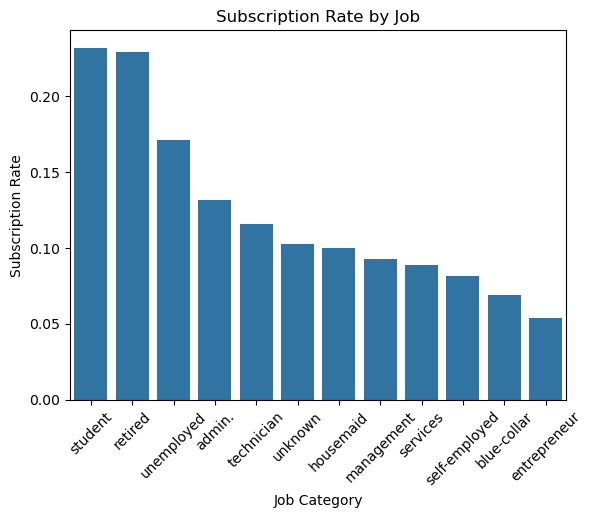

In [143]:
df_job_sorted = df_job.sort_values(by= 'perc_of_yes', ascending = False)
sns.barplot(x=df_job_sorted.index, y = df_job_sorted['perc_of_yes'])
plt.xticks(rotation=45)
plt.xlabel('Job Category')
plt.ylabel('Subscription Rate')
plt.title('Subscription Rate by Job')
plt.show()

In [144]:
#The barplot shows how subscription rates are different across the job categories. We can tell that students and retired people
#are more likely to subscribe than the rest of the job categories and the ones least likely to subscribe are blue-collars and entrepreneurs.

In [ ]:
#b

In [145]:
x = df_task3.drop('y', axis=1) #features
y = df_task3['y'] #target

In [146]:
y = y.map({'no':0 , 'yes':1})

In [149]:
encoded_x = pd.get_dummies(x, drop_first=True)

In [152]:
encoded_x.info() #to check if preprocessing was done right ( i need to have only floats, integers or booleans. no objects!!)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            4119 non-null   int64  
 1   duration                       4119 non-null   int64  
 2   campaign                       4119 non-null   int64  
 3   pdays                          4119 non-null   int64  
 4   previous                       4119 non-null   int64  
 5   emp.var.rate                   4119 non-null   float64
 6   cons.price.idx                 4119 non-null   float64
 7   cons.conf.idx                  4119 non-null   float64
 8   euribor3m                      4119 non-null   float64
 9   nr.employed                    4119 non-null   float64
 10  job_blue-collar                4119 non-null   bool   
 11  job_entrepreneur               4119 non-null   bool   
 12  job_housemaid                  4119 non-null   b